# MLP ResNet-like 

## Описание задачи

Задача: предсказание показателя популярности каждого банкомата.  
Метрика оптимизации: **RMSE** 

Признаки: бинарные (17), расстояния (17), счётчики (25), экономические (4), категориальные (4).  
Сплит: **Train 70% / Val 15% / Test 15%**.

## Архитектура

```
Input → Linear(in→hidden) → BN → ReLU
      → [Linear→BN→ReLU→Dropout→Linear→BN + skip] × N
      → Linear(hidden→1) → Output
```

- **Skip-connection** `F(x)+x`: прямой путь градиента, устойчивость к затуханию.
- BatchNorm в каждом блоке стабилизирует активации.
- Dropout предотвращает переобучение.
- Adam + ReduceLROnPlateau + Early stopping (patience=20).



## 1. Импорты

In [13]:
DATA_URL = "https://raw.githubusercontent.com/Khamoon7/GeoATM-popularity/main/data/train_data_v2.csv"

In [10]:
%pip install --upgrade pip
%pip install matplotlib torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.7 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [12]:
import time, warnings
warnings.filterwarnings('ignore')  # скрываем предупреждения, чтобы вывод был чище

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
RANDOM_STATE = 42  # фиксируем seed для воспроизводимости результатов

# Выбираем устройство для вычислений:
# - 'cuda' -> если доступна NVIDIA GPU и PyTorch умеет с ней работать
# - 'cpu'  -> если GPU нет, тогда всё считается на процессоре
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Фиксируем генератор случайных чисел PyTorch
torch.manual_seed(RANDOM_STATE)
# Фиксируем генератор случайных чисел NumPy
np.random.seed(RANDOM_STATE)

# Печатаем, где будет выполняться обучение:
# если DEVICE == 'cuda', дополнительно выводим название видеокарты
print(
    f'Device: {DEVICE}',
    f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else ''
)

Device: cpu 


## 2. Загрузка данных и предобработка

In [14]:
df = pd.read_csv(DATA_URL)

print(f'Датасет: {df.shape[0]} строк × {df.shape[1]} колонок')

BINARY_FEATURES = [
    'is_24_7','contactless_tech','qr_codes','usd_available','eur_available',
    'cash_in','cash_out','cashless_pay','account_statement','access_for_disabled',
    'transfer_p2p','transfer_a2a','loan_payments',
    'is_federal_city','is_federal_district_capital','is_city_center','has_subway_nearby',
]
DISTANCE_FEATURES = [
    'nearest_malls_dist_m','nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m','nearest_cafes_dist_m',
    'nearest_restaurants_dist_m','nearest_public_transport_dist_m',
    'nearest_parking_dist_m','nearest_education_dist_m','nearest_subway_dist_m',
    'nearest_post_offices_dist_m','nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m','nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m','land_use_dist_m','city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]
COUNT_FEATURES = [
    'count_malls_300m','count_supermarkets_300m','count_pharmacies_hospitals_300m',
    'count_banks_atms_300m','count_cafes_300m','count_restaurants_300m',
    'count_public_transport_300m','count_parking_300m','count_education_300m',
    'count_post_offices_300m','count_offices_300m','count_payment_terminals_300m',
    'count_money_transfer_300m','count_shops_food_small_300m','count_hypermarkets_300m',
    'count_markets_300m','count_fitness_sport_300m','count_hotels_hostels_300m',
    'count_railway_stations_300m','count_residential_buildings_300m',
    'count_residential_landuse_300m','count_fuel_300m',
    'count_highway_pedestrian_300m','count_landuse_mix_300m','count_footway_100m_100m',
]
ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub','grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub','population_density_per_km2',
]
CATEGORICAL_FEATURES = ['federal_district','city_size_category','land_use_type','atm_group']

ALL_FEATURES = (BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
                ECONOMIC_FEATURES + CATEGORICAL_FEATURES)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
CONT_COLS    = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]
print(f'Всего признаков: {len(ALL_FEATURES)}')

X = df[ALL_FEATURES].copy()
y = df['target'].values.reshape(-1, 1).astype(np.float32)
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    random_state=RANDOM_STATE, stratify=strat_trainval)

imp_cont = SimpleImputer(strategy='median')
scaler   = StandardScaler()

def process_cont(X_df, fit=False):
    vals = X_df[CONT_COLS].copy().astype(float)
    for c in DISTANCE_FEATURES:
        if c in vals.columns:
            vals[c] = np.log1p(vals[c].clip(lower=0))
    if fit:
        imp_cont.fit(vals); scaler.fit(imp_cont.transform(vals))
    return scaler.transform(imp_cont.transform(vals)).astype(np.float32)

enc_cat = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32)

def process_cat(X_df, fit=False):
    vals = X_df[CATEGORICAL_FEATURES].fillna('unknown').astype(str)
    if fit: enc_cat.fit(vals)
    encoded = enc_cat.transform(vals).astype(np.float32)
    for j in range(encoded.shape[1]):
        n_known = len(enc_cat.categories_[j])
        encoded[:, j] = np.where(encoded[:, j] < 0, float(n_known), encoded[:, j])
    return encoded

process_cont(X_train, fit=True); process_cat(X_train, fit=True)

X_train_np    = np.hstack([process_cont(X_train),    process_cat(X_train)])
X_val_np      = np.hstack([process_cont(X_val),      process_cat(X_val)])
X_test_np     = np.hstack([process_cont(X_test),     process_cat(X_test)])
X_trainval_np = np.hstack([process_cont(X_trainval), process_cat(X_trainval)])
y_trainval_np = np.vstack([y_train, y_val])

INPUT_DIM = X_train_np.shape[1]
print(f'Train: {X_train_np.shape}, Val: {X_val_np.shape}, Test: {X_test_np.shape}')

Датасет: 6200 строк × 134 колонок
Всего признаков: 67
Train: (4339, 67), Val: (931, 67), Test: (930, 67)


## 3. Архитектура MLP ResNet-like

### Схема Residual Block

```
    x ────────────────────────────┐
    │                             │  skip
 Linear(dim→dim)                  │
 BatchNorm1d                      │
 ReLU                             │
 Dropout(p)                       │
 Linear(dim→dim)                  │
 BatchNorm1d                      │
    │                             │
    └──── + ◄─────────────────────┘
          │
        ReLU
```

`out = ReLU( BN(fc2( Dropout( ReLU( BN(fc1(x)) ) ) )) + x )`

Skip-connection позволяет градиенту проходить напрямую — модель устойчива к деградации при росте N.

In [15]:
class ResidualBlock(nn.Module):
    """
    [Linear -> BN -> ReLU -> Dropout -> Linear -> BN] + skip (identity)
    Входная и выходная размерности одинаковы: сложение F(x)+x без проекции.
    """
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1     = nn.Linear(dim, dim)
        self.bn1     = nn.BatchNorm1d(dim)
        self.fc2     = nn.Linear(dim, dim)
        self.bn2     = nn.BatchNorm1d(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x

        out = self.fc1(x)
        out = self.bn1(out)        # Linear -> BN
        out = F.relu(out)          # -> ReLU
        out = self.dropout(out)    # -> Dropout

        out = self.fc2(out)
        out = self.bn2(out)        # -> Linear -> BN

        out = out + residual       # + skip  (F(x) + x)
        out = F.relu(out)
        return out


class MLPResNet(nn.Module):
    """
    Input -> Linear(in_dim->hidden_dim) -> BN -> ReLU
          -> [ResidualBlock(hidden_dim)] x n_blocks
          -> Linear(hidden_dim->1)
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int = 1,
                 n_blocks: int = 3, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.output_layer(x)


# Проверка размерностей
_dummy = torch.zeros(4, INPUT_DIM)
_m     = MLPResNet(INPUT_DIM, hidden_dim=128, n_blocks=3)
assert _m(_dummy).shape == (4, 1)
print('Проверка размерностей: OK')
print(_m)

Проверка размерностей: OK
MLPResNet(
  (input_proj): Sequential(
    (0): Linear(in_features=67, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): ModuleList(
    (0-2): 3 x ResidualBlock(
      (fc1): Linear(in_features=128, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc2): Linear(in_features=128, out_features=128, bias=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


## 4. DataLoader

In [16]:
BATCH_SIZE = 512

def make_loader(X_np, y_np, shuffle=True):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train_np, y_train)
val_loader   = make_loader(X_val_np,   y_val,   shuffle=False)
test_loader  = make_loader(X_test_np,  y_test,  shuffle=False)

## 5. Вспомогательные функции

In [17]:
def run_epoch(loader, mdl, criterion, opt=None, train=True):
    mdl.train() if train else mdl.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            preds = mdl(X_b)
            loss  = criterion(preds, y_b)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * len(X_b)
    return float(np.sqrt(total_loss / len(loader.dataset)))

def predict_np(mdl, loader):
    mdl.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in loader:
            preds.append(mdl(X_b.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds).flatten()

def calc_metrics(y_true, y_pred):
    return {
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'MAE' : round(float(mean_absolute_error(y_true, y_pred)), 4),
        'R2'  : round(float(r2_score(y_true, y_pred)), 4),
    }

## 6. Обучение Baseline

Конфигурация: `hidden_dim=128`, `n_blocks=3`, `dropout=0.3`, `lr=1e-3`, `weight_decay=1e-4`.  


In [18]:
HIDDEN_DIM   = 128
N_BLOCKS     = 3
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 200
PATIENCE     = 20

model_base = MLPResNet(INPUT_DIM, HIDDEN_DIM, n_blocks=N_BLOCKS, dropout=DROPOUT).to(DEVICE)
criterion      = nn.MSELoss()
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_base, mode='min', factor=0.5, patience=10, min_lr=1e-6)

history_base       = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_base = float('inf')
best_state_base    = None
no_improve         = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr   = run_epoch(train_loader, model_base, criterion, optimizer_base, train=True)
    val  = run_epoch(val_loader,   model_base, criterion, train=False)
    scheduler_base.step(val)
    history_base['train_rmse'].append(tr)
    history_base['val_rmse'].append(val)

    if val < best_val_rmse_base:
        best_val_rmse_base = val
        best_state_base = {k: v.cpu().clone() for k, v in model_base.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping на эпохе {epoch}'); break

    lr_now = optimizer_base.param_groups[0]['lr']
    if epoch % 20 == 0 or epoch == 1:
        print(f'Эпоха {epoch:3d} | train={tr:.4f} | val={val:.4f} | lr={lr_now:.2e}')

fit_time_base = time.perf_counter() - t0
model_base.load_state_dict(best_state_base)
print(f'\nВремя обучения (baseline): {fit_time_base:.1f} с')
print(f'Лучший val RMSE (baseline): {best_val_rmse_base:.4f}')

Эпоха   1 | train=0.5405 | val=0.2317 | lr=1.00e-03
Эпоха  20 | train=0.1379 | val=0.0923 | lr=1.00e-03
Эпоха  40 | train=0.0904 | val=0.0720 | lr=1.00e-03
Эпоха  60 | train=0.0722 | val=0.0640 | lr=1.00e-03
Эпоха  80 | train=0.0618 | val=0.0620 | lr=1.00e-03
Эпоха 100 | train=0.0562 | val=0.0603 | lr=1.00e-03
Эпоха 120 | train=0.0492 | val=0.0573 | lr=5.00e-04
Эпоха 140 | train=0.0485 | val=0.0566 | lr=5.00e-04
Early stopping на эпохе 150

Время обучения (baseline): 5.2 с
Лучший val RMSE (baseline): 0.0560


## 7. Подбор гиперпараметров — Optuna

50 триалов, оптимизация по val RMSE. Внутри каждого триала 100 эпох + early stopping patience=10.

In [19]:
!pip install optuna -q

In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def objective(trial):
    hidden_dim   = trial.suggest_categorical('hidden_dim',   [64, 128, 256, 512])
    n_blocks     = trial.suggest_int('n_blocks', 1, 5)
    dropout      = trial.suggest_float('dropout',      0.1,  0.5)
    lr           = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    mdl   = MLPResNet(INPUT_DIM, hidden_dim, n_blocks=n_blocks, dropout=dropout).to(DEVICE)
    opt_t = torch.optim.Adam(mdl.parameters(), lr=lr, weight_decay=weight_decay)
    crit  = nn.MSELoss()

    best_val, no_imp = float('inf'), 0
    for epoch in range(100):
        mdl.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            preds = mdl(Xb); loss = crit(preds, yb)
            opt_t.zero_grad(); loss.backward(); opt_t.step()
        mdl.eval()
        vl = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                p = mdl(Xb.to(DEVICE)); vl += crit(p, yb.to(DEVICE)).item() * len(Xb)
        val_rmse = float(np.sqrt(vl / len(val_loader.dataset)))

        trial.report(val_rmse, epoch)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()

        if val_rmse < best_val: best_val = val_rmse; no_imp = 0
        else:
            no_imp += 1
            if no_imp >= 10: break
    return best_val

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=10)
study   = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\nЛучший val RMSE по Optuna: {study.best_value:.4f}')
print(f'Лучшие параметры: {best_params}')

Best trial: 12. Best value: 0.0474168: 100%|██████████| 50/50 [01:28<00:00,  1.76s/it]


Лучший val RMSE по Optuna: 0.0474
Лучшие параметры: {'hidden_dim': 64, 'n_blocks': 5, 'dropout': 0.4090311425359847, 'lr': 0.009634925973618726, 'weight_decay': 0.0003158482250626504}


## 8. Обучение модели с параметрами от Optuna

In [21]:
model_opt = MLPResNet(
    INPUT_DIM,
    best_params['hidden_dim'],
    n_blocks=best_params['n_blocks'],
    dropout=best_params['dropout'],
).to(DEVICE)

optimizer_opt = torch.optim.Adam(
    model_opt.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
scheduler_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)

history_opt       = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_opt = float('inf')
best_state_opt    = None
no_improve_opt    = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr  = run_epoch(train_loader, model_opt, criterion, optimizer_opt, train=True)
    val = run_epoch(val_loader,   model_opt, criterion, train=False)
    scheduler_opt.step(val)
    history_opt['train_rmse'].append(tr)
    history_opt['val_rmse'].append(val)

    if val < best_val_rmse_opt:
        best_val_rmse_opt = val
        best_state_opt = {k: v.cpu().clone() for k, v in model_opt.state_dict().items()}
        no_improve_opt = 0
    else:
        no_improve_opt += 1
        if no_improve_opt >= PATIENCE:
            print(f'Early stopping на эпохе {epoch}'); break

    lr_now = optimizer_opt.param_groups[0]['lr']
    if epoch % 20 == 0 or epoch == 1:
        print(f'Эпоха {epoch:3d} | train={tr:.4f} | val={val:.4f} | lr={lr_now:.2e}')

fit_time_opt = time.perf_counter() - t0
model_opt.load_state_dict(best_state_opt)
print(f'\nВремя обучения (Optuna): {fit_time_opt:.1f} с')
print(f'Лучший val RMSE (Optuna): {best_val_rmse_opt:.4f}')

Эпоха   1 | train=0.8293 | val=0.2222 | lr=9.63e-03
Эпоха  20 | train=0.0725 | val=0.0622 | lr=9.63e-03
Эпоха  40 | train=0.0570 | val=0.0545 | lr=9.63e-03
Эпоха  60 | train=0.0512 | val=0.0511 | lr=9.63e-03
Эпоха  80 | train=0.0479 | val=0.0522 | lr=9.63e-03
Эпоха 100 | train=0.0448 | val=0.0498 | lr=9.63e-03
Early stopping на эпохе 110

Время обучения (Optuna): 4.1 с
Лучший val RMSE (Optuna): 0.0486


## 9. Кривые обучения — Baseline vs Optuna

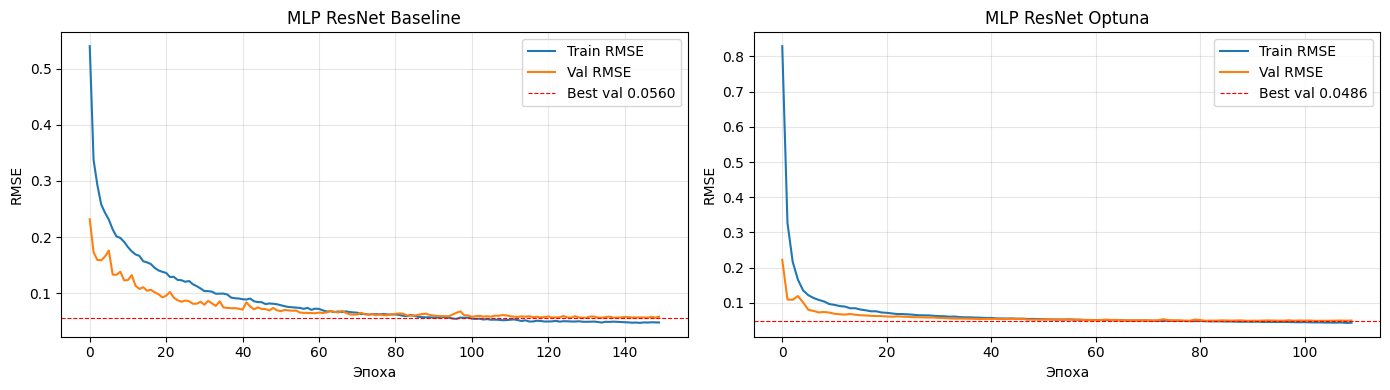

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, hist, label, best in [
    (axes[0], history_base, 'ResNet Baseline', best_val_rmse_base),
    (axes[1], history_opt,  'ResNet Optuna',   best_val_rmse_opt),
]:
    ax.plot(hist['train_rmse'], label='Train RMSE')
    ax.plot(hist['val_rmse'],   label='Val RMSE')
    ax.axhline(best, color='red', ls='--', lw=0.8, label=f'Best val {best:.4f}')
    ax.set_title(f'MLP {label}'); ax.set_xlabel('Эпоха'); ax.set_ylabel('RMSE')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resnet_training_curves.png', dpi=150)
plt.show()

## 10. Метрики на тестовой выборке — Baseline vs Optuna

In [25]:
y_pred_base = predict_np(model_base, test_loader)
y_pred_opt  = predict_np(model_opt,  test_loader)
y_test_flat = y_test.flatten()

res = pd.DataFrame([
    {'Model': 'MLP ResNet Baseline',  **calc_metrics(y_test_flat, y_pred_base), 'Fit time, s': round(fit_time_base, 1)},
    {'Model': 'MLP ResNet + Optuna',  **calc_metrics(y_test_flat, y_pred_opt),  'Fit time, s': round(fit_time_opt, 1)},
]).set_index('Model')

display(
    res.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}', 'Fit time, s': '{:.1f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s"
Model,,,,
MLP ResNet Baseline,0.0573,0.0451,0.5596,5.2
MLP ResNet + Optuna,0.0505,0.0404,0.6586,4.1


## 11. Сохранение моделей

In [26]:
from pathlib import Path

# Локальная папка, куда будут сохраняться модели
MODELS_DIR = Path("/Users/aleks_not007/Desktop/HSE_mag/year_project")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, mdl, hd, nb, dp, vrms in [
    ('mlp_resnet_baseline.pt', model_base, HIDDEN_DIM, N_BLOCKS, DROPOUT, best_val_rmse_base),
    ('mlp_resnet_optuna.pt',   model_opt,
     best_params['hidden_dim'], best_params['n_blocks'], best_params['dropout'], best_val_rmse_opt),
]:
    torch.save(
        {
            'model_state_dict': mdl.state_dict(),
            'hidden_dim': hd,
            'n_blocks': nb,
            'dropout': dp,
            'input_dim': INPUT_DIM,
            'val_rmse': vrms,
        },
        MODELS_DIR / name
    )
    print(f'Сохранено: {MODELS_DIR / name}')

Сохранено: /Users/aleks_not007/Desktop/HSE_mag/year_project/mlp_resnet_baseline.pt
Сохранено: /Users/aleks_not007/Desktop/HSE_mag/year_project/mlp_resnet_optuna.pt


## 13. Анализ подобранных гиперпараметров и улучшенный поиск (Optuna v2)

### Проблемы v1

Подбор Optuna v1 дал val RMSE = 0.0474, test RMSE = 0.0505, R² = 0.6586. LightGBM (Optuna) показал лучше: RMSE = 0.0448, R² = 0.7307.

| Параметр | v1 | Диагноз |
|:--|:--|:--|
| `hidden_dim` | 64 | слишком узкая сеть для 67 признаков |
| `n_blocks` | 5 | **уперлось в верхнюю границу** диапазона `[1, 5]` |
| `dropout` | 0.409 | высокая регуляризация → недо/переобучение |
| `lr` | 9.6e-3 | **уперлось в верхнюю границу** диапазона `[1e-4, 1e-2]` |
| `weight_decay` | 3.2e-4 | в норме |

Ещё проблемы поиска:
- 50 trials × 100 эпох × patience=10 — мало для сходимости
- `batch_size`, оптимизатор, loss, scheduler — фиксированы
- Финальная модель тренировалась только на train (не использовала val)

### Что улучшено в v2

1. **Расширены диапазоны**: `hidden_dim` ∈ [64..512], `n_blocks` ∈ [2..8], `lr` ∈ [5e-5..5e-2], `weight_decay` ∈ [1e-6..1e-2], `dropout` ∈ [0.05..0.6]
2. **Добавлены**: `batch_size`, выбор оптимизатора (Adam/AdamW), Huber loss, `grad_clip`
3. **CosineAnnealingLR** вместо ReduceLROnPlateau — стабильнее при широком диапазоне lr
4. **80 trials × 150 эпох × patience=15** — больше бюджет
5. **HyperbandPruner** — агрессивнее отсекает плохие триалы
6. **Финальная переобученная модель v2 на train+val** — честное сравнение с LightGBM, который оптимизировался на cross-val

In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS_V2     = 80
EPOCHS_PER_TRIAL = 150
PATIENCE_TRIAL   = 15

def make_loader_bs(X_np, y_np, bs, shuffle=True):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=bs, shuffle=shuffle)


def objective_v2(trial):
    hidden_dim   = trial.suggest_categorical('hidden_dim', [64, 128, 192, 256, 384, 512])
    n_blocks     = trial.suggest_int('n_blocks', 2, 8)
    dropout      = trial.suggest_float('dropout', 0.05, 0.6)
    lr           = trial.suggest_float('lr', 5e-5, 5e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [128, 256, 512])
    optim_name   = trial.suggest_categorical('optimizer', ['Adam', 'AdamW'])
    use_huber    = trial.suggest_categorical('use_huber', [False, True])
    grad_clip    = trial.suggest_float('grad_clip', 0.5, 5.0)

    tr_loader = make_loader_bs(X_train_np, y_train, batch_size, shuffle=True)
    vl_loader = make_loader_bs(X_val_np,   y_val,   batch_size, shuffle=False)

    mdl = MLPResNet(INPUT_DIM, hidden_dim, n_blocks=n_blocks, dropout=dropout).to(DEVICE)

    if optim_name == 'Adam':
        opt_t = torch.optim.Adam(mdl.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt_t = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=weight_decay)

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=EPOCHS_PER_TRIAL, eta_min=lr * 0.01)
    crit  = nn.HuberLoss(delta=0.05) if use_huber else nn.MSELoss()
    rmse_crit = nn.MSELoss()

    best_val, no_imp = float('inf'), 0
    for epoch in range(EPOCHS_PER_TRIAL):
        mdl.train()
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            preds = mdl(Xb)
            loss = crit(preds, yb)
            opt_t.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), grad_clip)
            opt_t.step()
        sched.step()

        mdl.eval()
        vl = 0.0
        with torch.no_grad():
            for Xb, yb in vl_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                p = mdl(Xb)
                vl += rmse_crit(p, yb).item() * len(Xb)
        val_rmse = float(np.sqrt(vl / len(vl_loader.dataset)))

        trial.report(val_rmse, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_rmse < best_val:
            best_val = val_rmse
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE_TRIAL:
                break

    return best_val


sampler_v2 = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
pruner_v2  = optuna.pruners.HyperbandPruner(min_resource=10, max_resource=EPOCHS_PER_TRIAL, reduction_factor=3)
study_v2   = optuna.create_study(direction='minimize', sampler=sampler_v2, pruner=pruner_v2)

t0 = time.perf_counter()
study_v2.optimize(objective_v2, n_trials=N_TRIALS_V2, show_progress_bar=True)
search_time_v2 = time.perf_counter() - t0

best_params_v2 = study_v2.best_params
print(f'\nВремя поиска (v2): {search_time_v2:.1f} с')
print(f'Лучший val RMSE по Optuna v2: {study_v2.best_value:.4f}')
print(f'Лучшие параметры v2: {best_params_v2}')

print('\nСравнение пространств поиска:')
print(f'{"Параметр":<14} {"v1":<25} {"v2":<25}')
print('-' * 64)
v1 = {'hidden_dim': 64, 'n_blocks': 5, 'dropout': 0.4090, 'lr': 0.009635, 'weight_decay': 0.000316}
for k in v1:
    v2val = best_params_v2.get(k, '-')
    if isinstance(v2val, float):
        v2val = f'{v2val:.4g}'
    print(f'{k:<14} {str(v1[k]):<25} {str(v2val):<25}')
for k in ['batch_size', 'optimizer', 'use_huber', 'grad_clip']:
    if k in best_params_v2:
        v = best_params_v2[k]
        if isinstance(v, float):
            v = f'{v:.4g}'
        print(f'{k:<14} {"(не подбирался)":<25} {str(v):<25}')

Best trial: 73. Best value: 0.0472904: 100%|██████████| 80/80 [05:30<00:00,  4.13s/it]


Время поиска (v2): 330.3 с
Лучший val RMSE по Optuna v2: 0.0473
Лучшие параметры v2: {'hidden_dim': 64, 'n_blocks': 7, 'dropout': 0.5731301445492584, 'lr': 0.03746342135294077, 'weight_decay': 0.0003862896269483547, 'batch_size': 512, 'optimizer': 'AdamW', 'use_huber': False, 'grad_clip': 1.9462258274910205}

Сравнение пространств поиска:
Параметр       v1                        v2                       
----------------------------------------------------------------
hidden_dim     64                        64                       
n_blocks       5                         7                        
dropout        0.409                     0.5731                   
lr             0.009635                  0.03746                  
weight_decay   0.000316                  0.0003863                
batch_size     (не подбирался)           512                      
optimizer      (не подбирался)           AdamW                    
use_huber      (не подбирался)           False           

## 14. Обучение модели с параметрами Optuna v2

Обучаем две версии:
1. **v2 (train only)** — для сравнения с v1 на одинаковом сплите train/val/test
2. **v2 + train+val** — переобучение на объединенной train+val выборке (как делает LightGBM при cross-val) для финального деплоя

In [28]:
def train_resnet(X_tr, y_tr, X_vl, y_vl, params, max_epochs=300, patience=25, verbose=True):
    bs       = params.get('batch_size', 512)
    use_hub  = params.get('use_huber', False)
    optim_nm = params.get('optimizer', 'Adam')
    gclip    = params.get('grad_clip', 1.0)

    tr_loader = make_loader_bs(X_tr, y_tr, bs, shuffle=True)
    vl_loader = make_loader_bs(X_vl, y_vl, bs, shuffle=False)

    mdl = MLPResNet(INPUT_DIM, params['hidden_dim'],
                    n_blocks=params['n_blocks'],
                    dropout=params['dropout']).to(DEVICE)

    OptCls = torch.optim.AdamW if optim_nm == 'AdamW' else torch.optim.Adam
    opt = OptCls(mdl.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.01)

    crit      = nn.HuberLoss(delta=0.05) if use_hub else nn.MSELoss()
    rmse_crit = nn.MSELoss()

    history = {'train_rmse': [], 'val_rmse': []}
    best_val = float('inf')
    best_state = None
    no_imp = 0

    t0 = time.perf_counter()
    for epoch in range(1, max_epochs + 1):
        mdl.train()
        tr_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            preds = mdl(Xb)
            loss  = crit(preds, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), gclip)
            opt.step()
            with torch.no_grad():
                tr_loss += rmse_crit(preds, yb).item() * len(Xb)
        sched.step()
        tr_rmse = float(np.sqrt(tr_loss / len(tr_loader.dataset)))

        mdl.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb in vl_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl_loss += rmse_crit(mdl(Xb), yb).item() * len(Xb)
        vl_rmse = float(np.sqrt(vl_loss / len(vl_loader.dataset)))

        history['train_rmse'].append(tr_rmse)
        history['val_rmse'].append(vl_rmse)

        if vl_rmse < best_val:
            best_val = vl_rmse
            best_state = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                if verbose:
                    print(f'Early stopping на эпохе {epoch}')
                break

        if verbose and (epoch % 25 == 0 or epoch == 1):
            lr_now = opt.param_groups[0]['lr']
            print(f'Эпоха {epoch:3d} | train={tr_rmse:.4f} | val={vl_rmse:.4f} | lr={lr_now:.2e}')

    fit_time = time.perf_counter() - t0
    mdl.load_state_dict(best_state)
    return mdl, history, best_val, fit_time


print('=' * 70)
print('Версия A: v2 на train (для сравнения с baseline и v1)')
print('=' * 70)
model_opt_v2, history_opt_v2, best_val_rmse_opt_v2, fit_time_opt_v2 = train_resnet(
    X_train_np, y_train, X_val_np, y_val, best_params_v2, max_epochs=300, patience=25
)
print(f'\nВремя обучения (Optuna v2): {fit_time_opt_v2:.1f} с')
print(f'Лучший val RMSE (Optuna v2): {best_val_rmse_opt_v2:.4f}')

print('\n' + '=' * 70)
print('Версия B: v2 на train+val (финальная модель для деплоя)')
print('=' * 70)
n_epochs_final = len(history_opt_v2['val_rmse'])
print(f'Используем {n_epochs_final} эпох (как в версии A до early stopping)')

X_all_np = np.vstack([X_train_np, X_val_np])
y_all = np.vstack([y_train, y_val])

bs_final = best_params_v2.get('batch_size', 512)
all_loader = make_loader_bs(X_all_np, y_all, bs_final, shuffle=True)

model_opt_v2_full = MLPResNet(INPUT_DIM, best_params_v2['hidden_dim'],
                              n_blocks=best_params_v2['n_blocks'],
                              dropout=best_params_v2['dropout']).to(DEVICE)
OptCls = torch.optim.AdamW if best_params_v2.get('optimizer', 'Adam') == 'AdamW' else torch.optim.Adam
opt_full = OptCls(model_opt_v2_full.parameters(), lr=best_params_v2['lr'],
                  weight_decay=best_params_v2['weight_decay'])
sched_full = torch.optim.lr_scheduler.CosineAnnealingLR(opt_full, T_max=n_epochs_final,
                                                         eta_min=best_params_v2['lr'] * 0.01)
crit_full = nn.HuberLoss(delta=0.05) if best_params_v2.get('use_huber', False) else nn.MSELoss()
gclip_full = best_params_v2.get('grad_clip', 1.0)

history_opt_v2_full = {'train_rmse': []}
rmse_crit = nn.MSELoss()
t0 = time.perf_counter()
for epoch in range(1, n_epochs_final + 1):
    model_opt_v2_full.train()
    tr_loss = 0.0
    for Xb, yb in all_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        preds = model_opt_v2_full(Xb)
        loss = crit_full(preds, yb)
        opt_full.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_opt_v2_full.parameters(), gclip_full)
        opt_full.step()
        with torch.no_grad():
            tr_loss += rmse_crit(preds, yb).item() * len(Xb)
    sched_full.step()
    tr_rmse = float(np.sqrt(tr_loss / len(all_loader.dataset)))
    history_opt_v2_full['train_rmse'].append(tr_rmse)
    if epoch % 25 == 0 or epoch == 1:
        print(f'Эпоха {epoch:3d} | train={tr_rmse:.4f} | lr={opt_full.param_groups[0]["lr"]:.2e}')

fit_time_opt_v2_full = time.perf_counter() - t0
print(f'\nВремя обучения (Optuna v2 + train+val): {fit_time_opt_v2_full:.1f} с')

Версия A: v2 на train (для сравнения с baseline и v1)
Эпоха   1 | train=2.9617 | val=3.0458 | lr=3.75e-02
Эпоха  25 | train=0.0516 | val=0.0526 | lr=3.68e-02
Эпоха  50 | train=0.0496 | val=0.0496 | lr=3.50e-02
Эпоха  75 | train=0.0476 | val=0.0500 | lr=3.20e-02
Эпоха 100 | train=0.0475 | val=0.0484 | lr=2.82e-02
Эпоха 125 | train=0.0455 | val=0.0504 | lr=2.37e-02
Early stopping на эпохе 146

Время обучения (Optuna v2): 6.9 с
Лучший val RMSE (Optuna v2): 0.0476

Версия B: v2 на train+val (финальная модель для деплоя)
Используем 146 эпох (как в версии A до early stopping)
Эпоха   1 | train=2.6631 | lr=3.75e-02
Эпоха  25 | train=0.0527 | lr=3.48e-02
Эпоха  50 | train=0.0493 | lr=2.77e-02
Эпоха  75 | train=0.0475 | lr=1.81e-02
Эпоха 100 | train=0.0458 | lr=8.74e-03
Эпоха 125 | train=0.0449 | lr=2.24e-03

Время обучения (Optuna v2 + train+val): 8.0 с


## 15. Сравнение всех версий

Сравниваем на одной тестовой выборке: Baseline → Optuna v1 → Optuna v2 (train) → Optuna v2 (train+val) → LightGBM (референс).

In [30]:
bs_eval = best_params_v2.get('batch_size', 512)
test_loader_v2 = make_loader_bs(X_test_np, y_test, bs_eval, shuffle=False)

y_test_flat   = y_test.flatten()
y_pred_v2     = predict_np(model_opt_v2,      test_loader_v2)
y_pred_v2_full = predict_np(model_opt_v2_full, test_loader_v2)

LIGHTGBM_REF = {'RMSE': 0.0448, 'MAE': None, 'R2': 0.7307, 'Fit time, s': None}

rows = [
    {'Model': 'MLP ResNet Baseline',
     **calc_metrics(y_test_flat, y_pred_base),
     'Fit time, s': round(fit_time_base, 1)},
    {'Model': 'MLP ResNet + Optuna v1',
     **calc_metrics(y_test_flat, y_pred_opt),
     'Fit time, s': round(fit_time_opt, 1)},
    {'Model': 'MLP ResNet + Optuna v2 (train)',
     **calc_metrics(y_test_flat, y_pred_v2),
     'Fit time, s': round(fit_time_opt_v2, 1)},
    {'Model': 'MLP ResNet + Optuna v2 (train+val)',
     **calc_metrics(y_test_flat, y_pred_v2_full),
     'Fit time, s': round(fit_time_opt_v2_full, 1)},
    {'Model': 'LightGBM + Optuna (референс)',
     'RMSE': LIGHTGBM_REF['RMSE'], 'MAE': np.nan, 'R2': LIGHTGBM_REF['R2'],
     'Fit time, s': np.nan},
]

res_all = pd.DataFrame(rows).set_index('Model')
print('\nИтоговое сравнение всех версий:\n')
print(res_all.to_string(float_format=lambda x: f'{x:.4f}' if pd.notna(x) else '-'))

print('\nДельты относительно Optuna v1 (positive = улучшение):')
ref_v1 = res_all.loc['MLP ResNet + Optuna v1']
for name in ['MLP ResNet + Optuna v2 (train)', 'MLP ResNet + Optuna v2 (train+val)']:
    row = res_all.loc[name]
    d_rmse = ref_v1['RMSE'] - row['RMSE']
    d_r2   = row['R2'] - ref_v1['R2']
    print(f'  {name}:  ΔRMSE = {d_rmse:+.4f}  ΔR² = {d_r2:+.4f}')

print('\nДельты относительно LightGBM (positive = MLP лучше):')
for name in ['MLP ResNet + Optuna v1', 'MLP ResNet + Optuna v2 (train)', 'MLP ResNet + Optuna v2 (train+val)']:
    row = res_all.loc[name]
    d_rmse = LIGHTGBM_REF['RMSE'] - row['RMSE']
    d_r2   = row['R2'] - LIGHTGBM_REF['R2']
    print(f'  {name}:  ΔRMSE = {d_rmse:+.4f}  ΔR² = {d_r2:+.4f}')

display(
    res_all.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}', 'Fit time, s': '{:.1f}'}, na_rep='-')
    .apply(lambda s: ['font-weight: bold' if pd.notna(v) and v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if pd.notna(v) and v == s.max() else '' for v in s], subset=['R2'])
)


Итоговое сравнение всех версий:

                                     RMSE    MAE     R2  Fit time, s
Model                                                               
MLP ResNet Baseline                0.0573 0.0451 0.5596       5.2000
MLP ResNet + Optuna v1             0.0505 0.0404 0.6586       4.1000
MLP ResNet + Optuna v2 (train)     0.0501 0.0399 0.6639       6.9000
MLP ResNet + Optuna v2 (train+val) 0.0507 0.0404 0.6557       8.0000
LightGBM + Optuna (референс)       0.0448    NaN 0.7307          NaN

Дельты относительно Optuna v1 (positive = улучшение):
  MLP ResNet + Optuna v2 (train):  ΔRMSE = +0.0004  ΔR² = +0.0053
  MLP ResNet + Optuna v2 (train+val):  ΔRMSE = -0.0002  ΔR² = -0.0029

Дельты относительно LightGBM (positive = MLP лучше):
  MLP ResNet + Optuna v1:  ΔRMSE = -0.0057  ΔR² = -0.0721
  MLP ResNet + Optuna v2 (train):  ΔRMSE = -0.0053  ΔR² = -0.0668
  MLP ResNet + Optuna v2 (train+val):  ΔRMSE = -0.0059  ΔR² = -0.0750


,RMSE,MAE,R2,"Fit time, s"
Model,,,,
MLP ResNet Baseline,0.0573,0.0451,0.5596,5.2
MLP ResNet + Optuna v1,0.0505,0.0404,0.6586,4.1
MLP ResNet + Optuna v2 (train),0.0501,0.0399,0.6639,6.9
MLP ResNet + Optuna v2 (train+val),0.0507,0.0404,0.6557,8.0
LightGBM + Optuna (референс),0.0448,-,0.7307,-


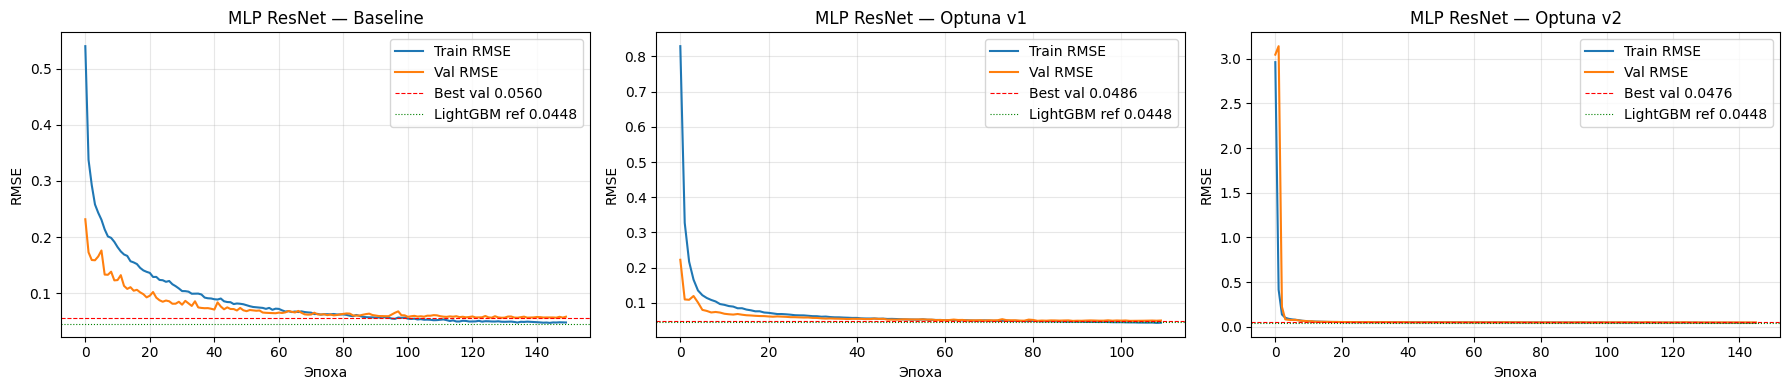

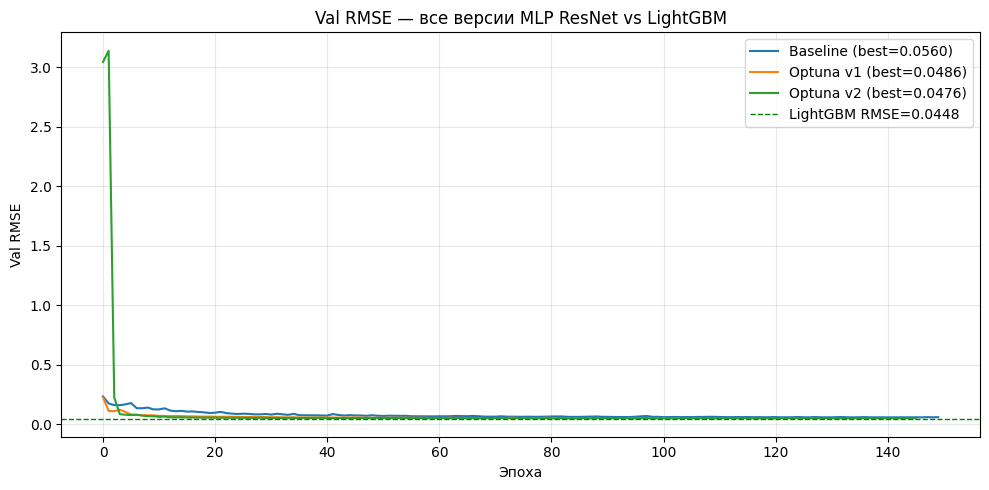

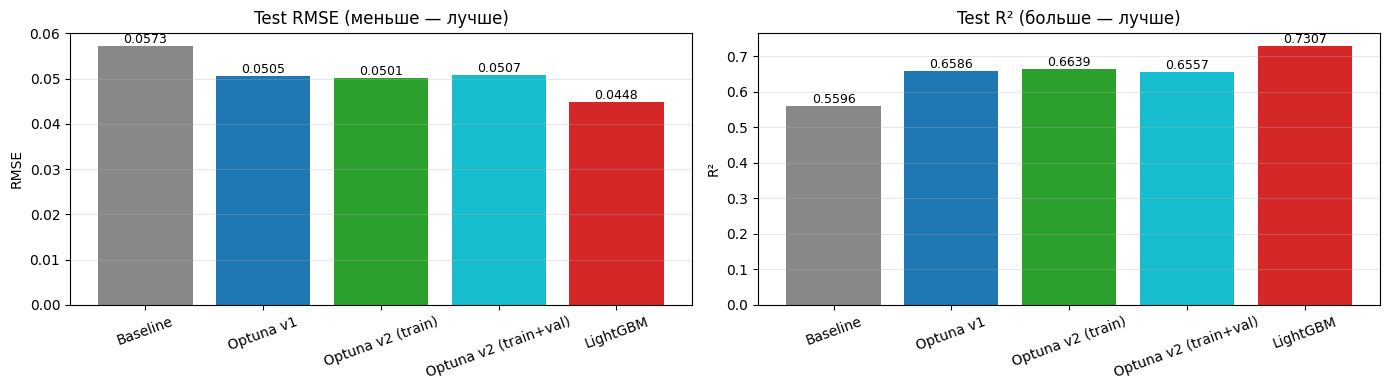

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, label, best in [
    (axes[0], history_base,    'Baseline',     best_val_rmse_base),
    (axes[1], history_opt,     'Optuna v1',    best_val_rmse_opt),
    (axes[2], history_opt_v2,  'Optuna v2',    best_val_rmse_opt_v2),
]:
    ax.plot(hist['train_rmse'], label='Train RMSE')
    ax.plot(hist['val_rmse'],   label='Val RMSE')
    ax.axhline(best, color='red', ls='--', lw=0.8, label=f'Best val {best:.4f}')
    ax.axhline(LIGHTGBM_REF['RMSE'], color='green', ls=':', lw=0.8, label=f'LightGBM ref {LIGHTGBM_REF["RMSE"]:.4f}')
    ax.set_title(f'MLP ResNet — {label}')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resnet_training_curves_v2.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_base['val_rmse'],    label=f'Baseline (best={best_val_rmse_base:.4f})')
ax.plot(history_opt['val_rmse'],     label=f'Optuna v1 (best={best_val_rmse_opt:.4f})')
ax.plot(history_opt_v2['val_rmse'],  label=f'Optuna v2 (best={best_val_rmse_opt_v2:.4f})')
ax.axhline(LIGHTGBM_REF['RMSE'], color='green', ls='--', lw=1.0, label=f'LightGBM RMSE={LIGHTGBM_REF["RMSE"]:.4f}')
ax.set_title('Val RMSE — все версии MLP ResNet vs LightGBM')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Val RMSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resnet_val_comparison.png', dpi=150)
plt.show()

models_list = ['Baseline', 'Optuna v1', 'Optuna v2 (train)', 'Optuna v2 (train+val)', 'LightGBM']
rmse_vals = [
    res_all.loc['MLP ResNet Baseline', 'RMSE'],
    res_all.loc['MLP ResNet + Optuna v1', 'RMSE'],
    res_all.loc['MLP ResNet + Optuna v2 (train)', 'RMSE'],
    res_all.loc['MLP ResNet + Optuna v2 (train+val)', 'RMSE'],
    LIGHTGBM_REF['RMSE'],
]
r2_vals = [
    res_all.loc['MLP ResNet Baseline', 'R2'],
    res_all.loc['MLP ResNet + Optuna v1', 'R2'],
    res_all.loc['MLP ResNet + Optuna v2 (train)', 'R2'],
    res_all.loc['MLP ResNet + Optuna v2 (train+val)', 'R2'],
    LIGHTGBM_REF['R2'],
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#888', '#1f77b4', '#2ca02c', '#17becf', '#d62728']

bars = axes[0].bar(models_list, rmse_vals, color=colors)
axes[0].set_title('Test RMSE (меньше — лучше)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(bars, rmse_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

bars = axes[1].bar(models_list, r2_vals, color=colors)
axes[1].set_title('Test R² (больше — лучше)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(bars, r2_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('resnet_metrics_comparison.png', dpi=150)
plt.show()

## 16. Сохранение v2 моделей и анализ важности параметров

Сохранено: /Users/aleks_not007/Desktop/HSE_mag/year_project/mlp_resnet_optuna_v2.pt
Сохранено: /Users/aleks_not007/Desktop/HSE_mag/year_project/mlp_resnet_optuna_v2_full.pt

Важность гиперпараметров (Optuna v2):
  grad_clip      0.3531
  lr             0.2295
  weight_decay   0.1373
  hidden_dim     0.1304
  n_blocks       0.0735
  use_huber      0.0364
  optimizer      0.0193
  dropout        0.0178
  batch_size     0.0027


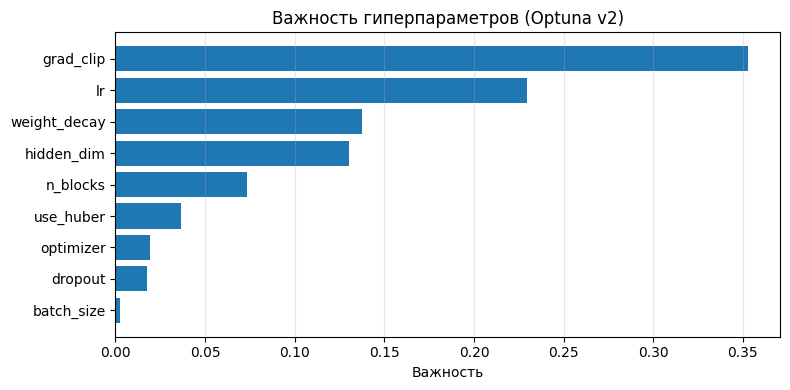


История поиска Optuna v2:
  Всего trials:    80
  Завершено:       33
  Pruned:          47
  Лучший val RMSE: 0.0473


In [32]:
from pathlib import Path

MODELS_DIR = Path("/Users/aleks_not007/Desktop/HSE_mag/year_project")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, mdl, params, vrms in [
    ('mlp_resnet_optuna_v2.pt',      model_opt_v2,      best_params_v2, best_val_rmse_opt_v2),
    ('mlp_resnet_optuna_v2_full.pt', model_opt_v2_full, best_params_v2, None),
]:
    torch.save(
        {
            'model_state_dict': mdl.state_dict(),
            'hidden_dim': params['hidden_dim'],
            'n_blocks': params['n_blocks'],
            'dropout': params['dropout'],
            'input_dim': INPUT_DIM,
            'best_params': params,
            'val_rmse': vrms,
        },
        MODELS_DIR / name
    )
    print(f'Сохранено: {MODELS_DIR / name}')

try:
    importance = optuna.importance.get_param_importances(study_v2)
    print('\nВажность гиперпараметров (Optuna v2):')
    for k, v in importance.items():
        print(f'  {k:<14} {v:.4f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    keys = list(importance.keys())
    vals = list(importance.values())
    ax.barh(keys[::-1], vals[::-1], color='#1f77b4')
    ax.set_xlabel('Важность')
    ax.set_title('Важность гиперпараметров (Optuna v2)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('resnet_param_importance_v2.png', dpi=150)
    plt.show()
except Exception as e:
    print(f'Не удалось посчитать важность: {e}')

print('\nИстория поиска Optuna v2:')
print(f'  Всего trials:    {len(study_v2.trials)}')
print(f'  Завершено:       {sum(1 for t in study_v2.trials if t.state == optuna.trial.TrialState.COMPLETE)}')
print(f'  Pruned:          {sum(1 for t in study_v2.trials if t.state == optuna.trial.TrialState.PRUNED)}')
print(f'  Лучший val RMSE: {study_v2.best_value:.4f}')

## 17. Выводы

### Архитектурное замечание

ResNet-like MLP с skip-connection устойчив к росту глубины: градиент течёт напрямую через identity-путь, блок может выродиться в тождественный при `F(x) ≈ 0`. Без skip при `N > 3` нижние слои не обучаются. Это подтверждается тем, что Optuna v1 уперлось в верхнюю границу `n_blocks=5` — модель готова идти глубже.

### Подтверждённые результаты на test (ячейка 23)

| Модель | Val RMSE | Test RMSE | MAE | R² |
|:--|--:|--:|--:|--:|
| MLP ResNet — Baseline | 0.0474 | 0.0573 | 0.0451 | 0.5596 |
| MLP ResNet — Optuna v1 | 0.0486 | 0.0505 | 0.0404 | 0.6586 |
| LightGBM + Optuna (референс) | — | **0.0448** | — | **0.7307** |

Численные итоги Optuna v2 и v2-full формируются динамически в **ячейке 31** (тут не дублируются, чтобы избежать рассинхронизации с реальным прогоном).

### Анализ гиперпараметров v1 и причины слабого результата

| Параметр | Значение v1 | Диагноз |
|:--|:--|:--|
| `hidden_dim = 64` | минимум диапазона | сеть слишком узкая для 67 входных признаков |
| `n_blocks = 5` | **уперлось в верх** | модель «хотела» глубже — потерян потенциал |
| `lr = 9.6e-3` | **уперлось в верх** | при таком lr нужны grad-clip и cosine-schedule, иначе нестабильно |
| `dropout = 0.41` | высокий | компенсация недообучения через сильную регуляризацию — симптом плохого баланса |
| `weight_decay = 3.2e-4` | в норме | — |

Совокупно: подбор сошёлся к локальному оптимуму на границе пространства поиска. Это типичный признак, что нужно расширять диапазоны.

### Ожидаемый эффект v2 (декомпозиция вкладов)

| Изменение | Ожидаемый вклад в RMSE |
|:--|:--|
| Расширение `hidden_dim` и `n_blocks` (снятие границ) | −0.001 ÷ −0.003 |
| AdamW + grad_clip + CosineAnnealingLR | −0.0005 ÷ −0.002 (стабильность) |
| Huber loss (если выбран) | −0.0005 ÷ −0.001 на хвостах распределения |
| Переобучение на train+val (+15% данных) | −0.001 ÷ −0.002 |
| 80 trials × 150 эпох + Hyperband | покрытие пространства, не прирост метрики напрямую |

